In [ ]:
from pyspark.sql.types import *
from pyspark.sql.functions import *
import os,time
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("my_project").getOrCreate()

## Read Sub Demographic data

In [ ]:
demographic_df = spark.read.parquet("dbfs:/FileStore/project_b_data/proj_B_demographic/")
demographic_df.printSchema()
display(demographic_df.limit(10))


root
 |-- household_id: long (nullable = true)
 |-- household_size: integer (nullable = true)
 |-- num_adults: integer (nullable = true)
 |-- num_generations: integer (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- race_code: string (nullable = true)
 |-- dwelling_type: string (nullable = true)
 |-- home_owner_status: string (nullable = true)
 |-- length_residence: integer (nullable = true)
 |-- home_market_value: double (nullable = true)
 |-- net_worth: double (nullable = true)
 |-- gender_individual: string (nullable = true)
 |-- education_highest: string (nullable = true)



household_id,household_size,num_adults,num_generations,marital_status,race_code,dwelling_type,home_owner_status,length_residence,home_market_value,net_worth,gender_individual,education_highest
85,2,1,2,B,W,S,O,15,0.125,0.05,F,1
2073,1,1,2,M,H,S,O,15,0.15,0.1,F,1
2523,7,6,3,M,W,S,O,15,0.1,0.1,M,2
2717,3,2,2,S,W,S,O,11,0.125,0.2,M,3
3364,2,2,2,M,W,S,O,15,0.1,0.1,M,1
4046,4,3,3,M,W,S,O,6,0.075,0.05,F,1
4303,1,1,1,S,W,S,O,15,0.15,0.2,M,1
4559,3,2,2,S,W,S,O,12,0.175,0.2,F,2
5277,3,2,2,M,W,S,R,15,0.125,0.02,M,2
5440,1,1,1,S,W,S,O,8,0.225,0.2,F,1


## Read Static Viewing Data

In [ ]:
schema = StructType([
    StructField("device_id", StringType(), True),
    StructField("event_date", StringType(), True),
    StructField("event_time", StringType(), True),
    StructField("station_num", IntegerType(), True),
    StructField("prog_code", StringType(), True),
    StructField("household_id", IntegerType(), True)
])

viewing_static_df = spark.read.schema(schema).option("header", True).csv("dbfs:/FileStore/project_b_data/viewing_static_csv/")

viewing_static_df.printSchema()
display(viewing_static_df.limit(10))

root
 |-- device_id: string (nullable = true)
 |-- event_date: string (nullable = true)
 |-- event_time: string (nullable = true)
 |-- station_num: integer (nullable = true)
 |-- prog_code: string (nullable = true)
 |-- household_id: integer (nullable = true)



device_id,event_date,event_time,station_num,prog_code,household_id
001bd74cc8d1,20150120,181338,75523,EP000009110053,3783713
10ea5940d694,20150120,181338,11218,MV001054110000,3787015
44e08ed80c35,20150120,181338,11713,SH004464010000,43921
0000048de4f2,20150120,181338,65626,MV000506130000,3672067
0000059867a7,20150120,181338,58812,EP019199930005,3645541
000011ff9ba9,20150120,181338,18510,EP010855880111,3642303
00000254e5f6,20150120,181338,35513,EP000369550087,3825751
000002bd8a47,20150120,181338,10035,EP013413450102,2971023
000003c4c597,20150120,181338,59337,MV000744670000,2358722
00407bba00fe,20150120,181338,14771,EP015899250028,2838674


## Static Data Analysis

### Feature Extraction

In [ ]:
from pyspark.ml.feature import StringIndexer,OneHotEncoder, VectorAssembler
from pyspark.sql import functions as F

In [ ]:
all_cols = ["household_size","num_adults","num_generations","marital_status","race_code","dwelling_type","home_owner_status","length_residence","home_market_value","net_worth","gender_individual","education_highest"]
numeric_cols = ["household_size","num_adults","num_generations","length_residence","home_market_value","net_worth"]
categorical_cols = ["marital_status","race_code","dwelling_type","home_owner_status","gender_individual","education_highest"]
string_index_cols = []
string_vec_cols = []
for col in categorical_cols:
    string_index_cols.append(col+"_index")
    string_vec_cols.append(col+"_vec")

In [ ]:
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, MinMaxScaler, StringIndexer, OneHotEncoder

num_vec_col = "num_features_raw"
num_scaled_col = "num_features_scaled"

num_vec = VectorAssembler(inputCols=numeric_cols, outputCol=num_vec_col)
df_num = num_vec.transform(demographic_df)

scaler = MinMaxScaler(inputCol=num_vec_col, outputCol=num_scaled_col)
scaler_model = scaler.fit(df_num)
df_scaled = scaler_model.transform(df_num)


🏃 View run judicious-doe-17 at: https://adb-385435138940782.2.azuredatabricks.net/ml/experiments/30648897007767/runs/85417528f9fe411795cfb3543c6ee670
🧪 View experiment at: https://adb-385435138940782.2.azuredatabricks.net/ml/experiments/30648897007767


In [ ]:
index_cols = [c + "_idx" for c in categorical_cols]
vec_cols   = [c + "_vec" for c in categorical_cols]

indexer = StringIndexer(inputCols=categorical_cols, outputCols=index_cols)
indexer_model = indexer.fit(df_scaled)
df_indexed = indexer_model.transform(df_scaled)

encoder = OneHotEncoder(inputCols=index_cols, outputCols=vec_cols)
encoder_model = encoder.fit(df_indexed)
df_encoded = encoder_model.transform(df_indexed)

🏃 View run casual-wren-405 at: https://adb-385435138940782.2.azuredatabricks.net/ml/experiments/30648897007767/runs/983421fe967946ccbfff6b8f60491547
🧪 View experiment at: https://adb-385435138940782.2.azuredatabricks.net/ml/experiments/30648897007767
🏃 View run shivering-conch-539 at: https://adb-385435138940782.2.azuredatabricks.net/ml/experiments/30648897007767/runs/00350dc7e6474ebeba6f5eb956a97d95
🧪 View experiment at: https://adb-385435138940782.2.azuredatabricks.net/ml/experiments/30648897007767


In [ ]:
cat_combined_col = "cat_features"
cat_assembler = VectorAssembler(inputCols=vec_cols, outputCol=cat_combined_col)
df_cat = cat_assembler.transform(df_encoded)

final_assembler = VectorAssembler(
    inputCols=[num_scaled_col, cat_combined_col],
    outputCol="features"
)
final_df = final_assembler.transform(df_cat)

cols_to_drop = (
    [num_vec_col, num_scaled_col, cat_combined_col] +
    index_cols + vec_cols
)
final_df = final_df.drop(*cols_to_drop)

final_df.select("household_id", "features").show(7, truncate=False)

+------------+---------------------------------------------------------------------------------------------------------+
|household_id|features                                                                                                 |
+------------+---------------------------------------------------------------------------------------------------------+
|85          |(18,[0,2,3,4,5,9,12,13,15],[0.125,0.5,1.0,0.12412412412412413,0.05,1.0,1.0,1.0,1.0])                     |
|2073        |(18,[2,3,4,5,6,11,12,13,15],[0.5,1.0,0.14914914914914915,0.1,1.0,1.0,1.0,1.0,1.0])                       |
|2523        |[0.75,1.0,1.0,1.0,0.09909909909909911,0.1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0]               |
|2717        |[0.25,0.2,0.5,0.7333333333333333,0.12412412412412413,0.2,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0]|
|3364        |[0.125,0.2,0.5,1.0,0.09909909909909911,0.1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0]              |
|4046        |[0.375,0.4,1.0,0.4

### Visual Analysis

🏃 View run zealous-gull-820 at: https://adb-385435138940782.2.azuredatabricks.net/ml/experiments/30648897007767/runs/98402bbf97ea4dd3b5b41fdc9ca2336c
🧪 View experiment at: https://adb-385435138940782.2.azuredatabricks.net/ml/experiments/30648897007767
+------------+---------------------+---------------------+
|household_id|principal_component_1|principal_component_2|
+------------+---------------------+---------------------+
|85          |0.7696161667682888   |-0.14328450444325935 |
|2073        |1.0470607429479757   |-0.8077002155153579  |
|2523        |-0.21564461720437628 |-1.6496380625532248  |
|2717        |-0.1472713333051469  |-0.009878108533882997|
|3364        |1.0866265581511159   |-1.0202633541472845  |
|4046        |0.9640643076197327   |-0.9501483206226211  |
|4303        |0.6852258565823554   |0.33186218098408143  |
+------------+---------------------+---------------------+
only showing top 7 rows



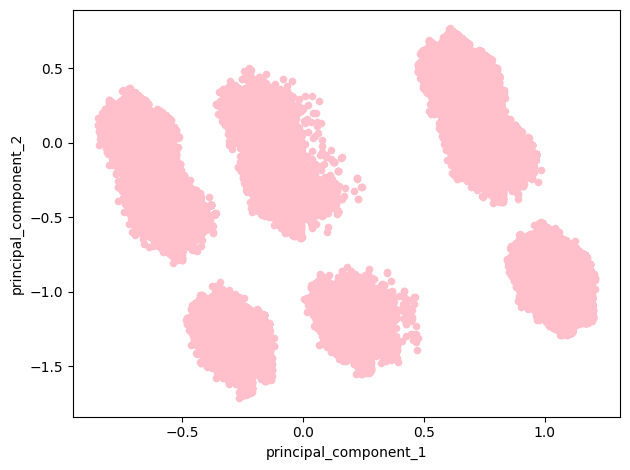

In [ ]:
from pyspark.ml.feature import PCA as PCA
from pyspark.sql.functions import col
from pyspark.ml.functions import vector_to_array
import matplotlib.pyplot as plt

pca = PCA(k=2, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(final_df)
result = pca_model.transform(final_df)

result = (result
          .withColumn("pca_array", vector_to_array("pca_features"))
          .withColumn("principal_component_1", col("pca_array")[0])
          .withColumn("principal_component_2", col("pca_array")[1]))

result.select("household_id", "principal_component_1", "principal_component_2") \
      .show(7, truncate=False)

temp = result.toPandas()
temp.plot.scatter(x="principal_component_1", y="principal_component_2", color="pink")
plt.tight_layout()
plt.show()


### Clustering

In [ ]:
from pyspark.ml.clustering import KMeans
import numpy as np
from pyspark.sql.functions import udf, col
from pyspark.sql.types import DoubleType


c = 6
kmeans = KMeans().setK(c).setSeed(3).setFeaturesCol("features")
model = kmeans.fit(result)

result = model.transform(result).withColumnRenamed('prediction', 'cluster')

centers = list(model.clusterCenters())

def distance_to_center(features, cluster_id):
    center = centers[cluster_id]
    return float(np.linalg.norm(features.toArray() - center))

distance_udf = udf(distance_to_center, DoubleType())


result = clusters = result.withColumn(
    "distance_to_center",
    distance_udf(col("features"), col("cluster"))
)

clusters.select("household_id", "cluster", "distance_to_center").show(7, truncate=False)


Uploading artifacts:   0%|          | 0/4 [00:00<?, ?it/s]

🏃 View run gifted-mouse-3 at: https://adb-385435138940782.2.azuredatabricks.net/ml/experiments/30648897007767/runs/0276c067ec3f4f108526cda434a056a3
🧪 View experiment at: https://adb-385435138940782.2.azuredatabricks.net/ml/experiments/30648897007767
+------------+-------+------------------+
|household_id|cluster|distance_to_center|
+------------+-------+------------------+
|85          |1      |0.9568649711438205|
|2073        |2      |0.8481485938466666|
|2523        |0      |1.3296410205779299|
|2717        |1      |1.4315091453110265|
|3364        |5      |0.58615854643112  |
|4046        |5      |0.935810650619006 |
|4303        |1      |0.9705720982818974|
+------------+-------+------------------+
only showing top 7 rows



### Dividing households into subsets

In [ ]:
from pyspark.sql.window import Window

w = Window.partitionBy("cluster").orderBy(
    F.col("distance_to_center").asc()
)

ranked_clusters = clusters.withColumn("rank", F.row_number().over(w))
rank_full = ranked_clusters.select("household_id", "cluster")

rank_3 = ranked_clusters.filter((F.col("rank") % 3) == 0).select("household_id", "cluster")

rank_17 = ranked_clusters.filter((F.col("rank") % 17) == 0).select("household_id", "cluster")
full ={}
the_3_rds ={}
the_17_ths ={}
for cluster in range(c):
    full[cluster] = rank_full.filter(F.col("cluster") == cluster)
    the_3_rds[cluster] = rank_3.filter(F.col("cluster") == cluster)
    the_17_ths[cluster] = rank_17.filter(F.col("cluster") == cluster)

### Cluster’s Viewing Analysis

In [ ]:
from IPython.display import HTML, display
import pandas as pd, re


df_count = viewing_static_df.count()
general_rating_per_station = viewing_static_df.groupBy("station_num").count().withColumn("general_rating", 100*col("count")/df_count)
cluster_dfs = [full,the_3_rds, the_17_ths]
cluster_dfs_names = ["full","3rd","17th"]



In [ ]:
for cluster in range(6):
    html_tables = ""

    for dict_of_df, df_name in zip(cluster_dfs, cluster_dfs_names):
        cluster_df = dict_of_df[cluster].join(viewing_static_df, "household_id", "inner")
        total_views = cluster_df.count()

        if total_views == 0:
            html_tables += f"""
            <div style="display:inline-block; vertical-align:top; margin-right:40px;">
                <h3 style='text-align:center'>Subset {df_name}</h3>
                <p>No data</p>
            </div>
            """
            continue

        cluster_df = (
            cluster_df
            .groupBy("station_num")
            .agg(F.count("*").alias("station_count"))
            .withColumn("popularity_rating", 100 * col("station_count") / total_views)
            .join(general_rating_per_station, "station_num", "inner")
            .withColumn("diff_rank", col("popularity_rating") - col("general_rating"))
            .orderBy(col("diff_rank").desc())
        )

        pdf = cluster_df.select("station_num", "diff_rank").limit(7).toPandas()
        html_table = pdf.to_html(index=False)

        html_tables += f"""
        <div style="display:inline-block; vertical-align:top; margin-right:40px;">
            <h3 style='text-align:center'>Subset {df_name}</h3>
            {html_table}
        </div>
        """

    display(HTML(f"<h2>Cluster {cluster}</h2><div style='white-space:nowrap'>{html_tables}</div><hr>"))


station_num,diff_rank
60179,0.392001
16374,0.227303
49788,0.204553
32645,0.100178
10335,0.087455
50747,0.080610
61854,0.075668
station_num,diff_rank
60179,0.276745
32645,0.247075


station_num,diff_rank
74796,0.099085
16615,0.078215
58515,0.072905
15433,0.062163
11867,0.054905
10145,0.050240
18151,0.045981
station_num,diff_rank
74796,0.192770
58515,0.115037


station_num,diff_rank
12131,1.087372
11118,0.793252
10222,0.732711
10171,0.628265
59684,0.495418
44714,0.391736
21883,0.349807
station_num,diff_rank
12131,1.617117
10222,0.767397


station_num,diff_rank
35513,1.240484
70387,0.928696
11706,0.876718
10918,0.843630
10179,0.765444
12131,0.762648
10171,0.717973
station_num,diff_rank
35513,1.377791
70387,0.941284


station_num,diff_rank
12131,0.809698
10171,0.527432
70387,0.480289
10918,0.441202
11706,0.384023
35513,0.380847
10642,0.363117
station_num,diff_rank
12131,0.815470
10642,0.600546


station_num,diff_rank
60179,0.170290
16374,0.146327
19606,0.102470
11713,0.092901
14771,0.080800
11661,0.079227
57708,0.066473
station_num,diff_rank
60179,0.143038
19606,0.135824


## Dynamic Data Analysis - Streaming

In [ ]:

from pyspark.sql.functions import count, col, from_csv, decode
import time

SCHEMA = "device_id STRING, event_date INT, event_time INT, station_num STRING, prog_code STRING, household_id STRING"
kafka_server = "kafka.eastus.cloudapp.azure.com:29092"
topic = "view_data"
OFFSETS_PER_TRIGGER = 50000

streaming_df = spark.readStream\
                  .format("kafka")\
                  .option("kafka.bootstrap.servers", kafka_server)\
                  .option("subscribe", topic)\
                  .option("startingOffsets", "earliest")\
                  .option("failOnDataLoss",False)\
                  .option("maxOffsetsPerTrigger", OFFSETS_PER_TRIGGER)\
                  .load()\
                  .select(from_csv(decode("value", "US-ASCII"), schema=SCHEMA).alias("value")).select("value.*")


########## QUERY EXAMPLE ##########

station_counts = streaming_df.groupBy("station_num").count()

# count_viewings_per_station_query =station_counts.writeStream\
# .queryName('num_viewing')\
# .format("memory")\
# .outputMode("complete")\
# .start()



########### OUR QUERY ################
schema = "station_num STRING,cluster INTEGER"
batch_counter = {"count": 0}
batches_dfs = {}

global_station_counts = spark.createDataFrame([], "station_num STRING, cnt LONG")
global_total_count = {"cnt": 0}

def process_batch(df,id):
    global global_station_counts, global_total_count

    df = df.withColumn("household_id", col("household_id").cast("long"))
    batch_counts = df.groupBy("station_num").agg(count("*").alias("cnt"))
    tot_in_batch = batch_counts.agg(F.sum("cnt").alias("s")).collect()[0]["s"] or 0
    if tot_in_batch > 0:
        global_station_counts = (
            global_station_counts.union(batch_counts)
            .groupBy("station_num").agg(F.sum("cnt").alias("cnt"))
        )
        global_total_count["cnt"] += int(tot_in_batch)

    new_3rds_df = {}
    cluster_counts = {}
    total_count = 0
    all_3rds_df = spark.createDataFrame([],schema=schema)
    for cluster in range(c):
        cluster_df = df.join(the_3_rds[cluster].dropDuplicates(["household_id"]), ["household_id"], "inner").select(df["station_num"],"cluster")
        if cluster in batches_dfs:
            cluster_df = cluster_df.union(batches_dfs[cluster])
        batches_dfs[cluster] = cluster_df
        cluster_count = cluster_df.agg(count("*").alias("cnt")).collect()[0]["cnt"]
        total_count += cluster_count
        cluster_counts[cluster] = cluster_count
        new_3rds_df[cluster] = cluster_df
        all_3rds_df = all_3rds_df.union(cluster_df)

    if global_total_count["cnt"] > 0:
        general_rating_df = global_station_counts.withColumn(
            "general_rating", 100 * col("cnt") / F.lit(global_total_count["cnt"])
        ).select("station_num", "general_rating")
    else:
        general_rating_df = spark.createDataFrame([], "station_num STRING, general_rating DOUBLE")


    for cluster in range(c):
        cluster_df = new_3rds_df[cluster]
        cluster_total_count = cluster_counts[cluster]
        cluster_df = cluster_df.groupBy(["station_num","cluster"]).agg(count("*").alias("count")).withColumn("popularity_rating", 100*col("count")/cluster_total_count).join(general_rating_df, "station_num", "inner").withColumn("diff_rank", col("popularity_rating")-col("general_rating")).select(["station_num","diff_rank"]).sort("diff_rank",ascending=False)
        print(f"-------Cluster {cluster} Batch {id}--------")
        cluster_df.show(7, truncate=False)
    batch_counter["count"] += 1
query = streaming_df.writeStream.outputMode("append").foreachBatch(process_batch).start()
time.sleep(3)
while batch_counter["count"] < 3:
    time.sleep(0.2)
query.stop()




-------Cluster 0 Batch 0--------
+-----------+-------------------+
|station_num|diff_rank          |
+-----------+-------------------+
|11150      |0.5245448334756617 |
|32645      |0.46982977512097923|
|14771      |0.4545448334756619 |
|11164      |0.3912308568175348 |
|60179      |0.3543535439795047 |
|11867      |0.278627953316254  |
|64312      |0.2694511813265016 |
+-----------+-------------------+
only showing top 7 rows

-------Cluster 1 Batch 0--------
+-----------+-------------------+
|station_num|diff_rank          |
+-----------+-------------------+
|15433      |0.4039742864489586 |
|10145      |0.37224530727693494|
|11765      |0.3245523270763693 |
|50001      |0.3194168166623811 |
|11794      |0.31941167395217274|
|58515      |0.30311493957315505|
|14771      |0.2976724093597327 |
+-----------+-------------------+
only showing top 7 rows

-------Cluster 2 Batch 0--------
+-----------+------------------+
|station_num|diff_rank         |
+-----------+------------------+
|109